# NB5 — RQ3: Bias mitigation strategies and the accuracy–fairness trade-off

**RQ3.** *Which bias mitigation strategies most effectively reduce disparity,
and what is the cost to overall predictive performance?*

### What this experiment can and cannot target — read first

The RQ1 audit on this corpus found **no statistically resolved accuracy gap**
between the Light and Medium tone bands (−0.020, 95% CI [−0.070, +0.026]),
and NB1b established there is **no auditable dark-skin population** in ACNE04
at all. Mitigation therefore cannot be evaluated against a large tone
accuracy gap here — there isn't one to close, and claiming otherwise would be
dishonest.

What the audit *did* find, and what this notebook targets:
1. **A calibration gap** — Light ECE 0.120 vs Medium 0.092. The model is more
   confidently wrong on the smaller group. This directly governs the
   abstention threshold in the demonstrator.
2. **Severe-class weakness** — grade 2 macro-F1 0.62 against 0.82 for grade 0,
   driven by class imbalance (186 vs 497 images).

Results are reported as a **trade-off curve with multi-seed uncertainty
bands**, not single-point claims, per the pre-committed protocol (§7.2).

GPU notebook — **Save & Run All**. Runtime ≈ `len(STRATEGIES) × SEEDS × 18min`.

**Attach input:** `lexuanhieu131297/acne-severity-classification`

In [1]:
import os, glob, re, math, json, time, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from PIL import Image
try:
    import timm
except ImportError:
    os.system("pip install timm -q"); import timm
try:
    import cv2
except ImportError:
    os.system("pip install opencv-python-headless -q"); import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

INPUT, WORK = "/kaggle/input", "/kaggle/working"
os.makedirs(WORK, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

# ---- config -------------------------------------------------------------
SMOKE_TEST = False          # True => 1 epoch, 2 strategies, 1 seed (~4 min)
STRATEGIES = ["erm", "class_reweight", "group_reweight", "oversample",
              "focal", "group_dro"]
SEEDS = [0, 1, 2]
EPOCHS = 18
BATCH = 32
LR = 3e-4
if SMOKE_TEST:
    STRATEGIES, SEEDS, EPOCHS = ["erm", "focal"], [0], 1
    print(">>> SMOKE_TEST ON — not a real run <<<")
RNG = np.random.default_rng(42)

device: cuda


## 1. Data: severity labels + validated (Method B) ITA tone bands

In [2]:
def find_dir(keys):
    best, best_n = None, -1
    for dp, _, _ in os.walk(INPUT):
        if any(k in os.path.basename(dp).lower() for k in keys):
            n = sum(1 for _, _, fs in os.walk(dp)
                    for f in fs if f.lower().endswith(IMG_EXT))
            if n > best_n:
                best, best_n = dp, n
    return best


def acne_label(p):
    m = re.search(r"lev[le]{0,2}\s*([0-3])", p.lower())
    return int(m.group(1)) if m else -1


def skin_mask(bgr):
    y = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb); cr, cb = y[:, :, 1], y[:, :, 2]
    m1 = (cr >= 133) & (cr <= 173) & (cb >= 77) & (cb <= 127)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    return m1 & (((h <= 25) | (h >= 165)) & (s >= 25) & (s <= 230) & (v >= 40))


def ita_method_b(path):
    """Validated Method B from NB1b: drop reddest 25% (acne), keep the
    brighter half (well-lit skin), median L*/b*."""
    img = cv2.imread(path)
    if img is None:
        return np.nan
    h, w = img.shape[:2]; s = 512 / max(h, w)
    if s < 1:
        img = cv2.resize(img, (int(w * s), int(h * s)))
    m = skin_mask(img)
    if m.sum() < 200:
        return np.nan
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
    L = lab[:, :, 0] * (100 / 255); a = lab[:, :, 1] - 128.0; b = lab[:, :, 2] - 128.0
    Ls, as_, bs = L[m], a[m], b[m]
    if len(Ls) < 100:
        return np.nan
    keep = as_ <= np.percentile(as_, 75)
    if keep.sum() >= 50:
        Ls, bs = Ls[keep], bs[keep]
    k2 = Ls >= np.median(Ls)
    Lm, bm = float(np.median(Ls[k2])), float(np.median(bs[k2]))
    return math.degrees(math.atan2(Lm - 50, bm)) if bm != 0 else np.nan


ACNE = find_dir(["acne"]); assert ACNE, "ACNE04 not attached"
paths = [os.path.join(dp, f) for dp, _, fs in os.walk(ACNE)
         for f in fs if f.lower().endswith(IMG_EXT)]

csv = glob.glob(os.path.join(INPUT, "**", "acne04_ita_validated.csv"),
                recursive=True)
if csv:
    print("reusing NB1b ITA table:", csv[0].replace(INPUT, ""))
    df = pd.read_csv(csv[0])
    df["tone_band"] = df["ita_B"].map(
        lambda v: "unknown" if pd.isna(v) else
        "Light" if v > 41 else "Medium" if v > 19 else "Deep")
else:
    print(f"computing Method-B ITA for {len(paths)} images ...")
    df = pd.DataFrame({"path": paths})
    df["ita_B"] = [ita_method_b(p) for p in df["path"]]
    df["tone_band"] = df["ita_B"].map(
        lambda v: "unknown" if pd.isna(v) else
        "Light" if v > 41 else "Medium" if v > 19 else "Deep")
if "label" not in df:
    df["label"] = df["path"].map(acne_label)
df = df[df["label"].between(0, 3)].reset_index(drop=True)

# audit groups: Light vs Medium only (Deep is an illumination artifact, NB1b)
df["group"] = df["tone_band"].where(df["tone_band"].isin(["Light", "Medium"]),
                                    "other")
print("\nseverity:\n", df["label"].value_counts().sort_index())
print("\ntone band:\n", df["tone_band"].value_counts())
classes = sorted(df["label"].unique()); n_cls = len(classes)
GROUPS = ["Light", "Medium"]

computing Method-B ITA for 1457 images ...

severity:
 label
0    497
1    637
2    186
3    137
Name: count, dtype: int64

tone band:
 tone_band
Medium    724
Light     538
Deep      195
Name: count, dtype: int64


## 2. Split, dataset, losses

In [3]:
df["strata"] = df["label"].astype(str) + "_" + df["tone_band"]
vc = df["strata"].value_counts()
df.loc[df["strata"].isin(vc[vc < 3].index), "strata"] = "rare"

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = T.Compose([T.Resize((224, 224)), T.RandomHorizontalFlip(),
                      T.RandomRotation(10),
                      T.ColorJitter(brightness=0.05, contrast=0.05),
                      T.ToTensor(), T.Normalize(MEAN, STD)])
eval_tf = T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize(MEAN, STD)])


class DS(Dataset):
    def __init__(self, frame, tf):
        self.p = frame["path"].values; self.y = frame["label"].values
        self.g = frame["tone_band"].values; self.tf = tf
    def __len__(self): return len(self.p)
    def __getitem__(self, i):
        return (self.tf(Image.open(self.p[i]).convert("RGB")),
                int(self.y[i]), self.g[i])


def collate(b):
    x, y, g = zip(*b)
    return torch.stack(x), torch.tensor(y), list(g)


class FocalLoss(nn.Module):
    """Down-weights easy examples; targets the rare severe grades."""
    def __init__(self, gamma=2.0, weight=None):
        super().__init__(); self.gamma = gamma; self.weight = weight
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight,
                             reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def ece_score(conf, correct, n_bins=10):
    conf = np.asarray(conf); correct = np.asarray(correct, float)
    bins = np.linspace(0, 1, n_bins + 1); e = 0.0; N = len(conf)
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i + 1])
        if m.sum():
            e += (m.sum() / N) * abs(correct[m].mean() - conf[m].mean())
    return e

## 3. One training run under a given mitigation strategy

In [4]:
def run(strategy, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    tr, te = train_test_split(df, test_size=0.25, random_state=seed,
                              stratify=df["strata"])

    # --- sampler / loss per strategy ---
    sampler, shuffle = None, True
    cls_w = None
    if strategy in ("class_reweight", "focal"):
        cnt = tr["label"].value_counts().reindex(classes).fillna(1).values
        cls_w = torch.tensor(cnt.sum() / (n_cls * cnt), dtype=torch.float32,
                             device=DEVICE)
    if strategy == "group_reweight":
        # weight each sample by inverse frequency of its (tone) group
        gc = tr["tone_band"].value_counts()
        wts = tr["tone_band"].map(lambda g: 1.0 / gc[g]).values
        sampler = WeightedRandomSampler(torch.DoubleTensor(wts), len(wts),
                                        replacement=True)
        shuffle = False
    if strategy == "oversample":
        # oversample rare (class, group) cells jointly
        cc = tr.groupby(["label", "tone_band"]).size()
        wts = tr.apply(lambda r: 1.0 / cc[(r["label"], r["tone_band"])],
                       axis=1).values
        sampler = WeightedRandomSampler(torch.DoubleTensor(wts), len(wts),
                                        replacement=True)
        shuffle = False

    tr_dl = DataLoader(DS(tr, train_tf), batch_size=BATCH, shuffle=shuffle,
                       sampler=sampler, num_workers=2, pin_memory=True,
                       collate_fn=collate)
    te_dl = DataLoader(DS(te, eval_tf), batch_size=BATCH, shuffle=False,
                       num_workers=2, pin_memory=True, collate_fn=collate)

    model = timm.create_model("resnet50", pretrained=True,
                              num_classes=n_cls).to(DEVICE)
    crit = (FocalLoss(weight=cls_w) if strategy == "focal"
            else nn.CrossEntropyLoss(weight=cls_w))
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda")
    # GroupDRO state: per-group adversarial weights
    g_idx = {g: i for i, g in enumerate(sorted(df["tone_band"].unique()))}
    q = torch.ones(len(g_idx), device=DEVICE) / len(g_idx)

    for ep in range(EPOCHS):
        model.train()
        for x, y, g in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
                out = model(x)
                if strategy == "group_dro":
                    per = F.cross_entropy(out, y, reduction="none")
                    gi = torch.tensor([g_idx[v] for v in g], device=DEVICE)
                    losses = torch.zeros(len(g_idx), device=DEVICE)
                    for k in range(len(g_idx)):
                        m = gi == k
                        if m.any():
                            losses[k] = per[m].mean()
                    q = q * torch.exp(0.01 * losses.detach())
                    q = q / q.sum()
                    loss = (q * losses).sum()
                else:
                    loss = crit(out, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()

    # --- evaluate ---
    model.eval(); rows = []
    with torch.no_grad():
        for x, y, g in te_dl:
            with torch.cuda.amp.autocast(enabled=DEVICE == "cuda"):
                prob = torch.softmax(model(x.to(DEVICE)), 1).float().cpu().numpy()
            pred = prob.argmax(1)
            for j in range(len(g)):
                rows.append(dict(g=g[j], y=int(y[j]), p=int(pred[j]),
                                 conf=float(prob[j].max())))
    r = pd.DataFrame(rows)
    out = dict(strategy=strategy, seed=seed,
               acc=accuracy_score(r.y, r.p),
               macro_f1=f1_score(r.y, r.p, average="macro"),
               f1_severe=f1_score(r.y, r.p, average=None,
                                  labels=[2], zero_division=0)[0])
    for g in GROUPS:
        s = r[r.g == g]
        out[f"acc_{g}"] = accuracy_score(s.y, s.p) if len(s) else np.nan
        out[f"ece_{g}"] = ece_score(s.conf, s.y == s.p) if len(s) else np.nan
    out["acc_gap"] = out["acc_Light"] - out["acc_Medium"]
    out["ece_gap"] = out["ece_Light"] - out["ece_Medium"]
    out["worst_group_acc"] = min(out["acc_Light"], out["acc_Medium"])
    return out

## 4. Run every strategy across seeds

In [5]:
results = []
for strat in STRATEGIES:
    for sd in SEEDS:
        t0 = time.time()
        res = run(strat, sd)
        results.append(res)
        print(f"{strat:15s} seed{sd}  acc={res['acc']:.4f}  "
              f"macroF1={res['macro_f1']:.4f}  |acc_gap|={abs(res['acc_gap']):.4f}  "
              f"|ece_gap|={abs(res['ece_gap']):.4f}  ({time.time()-t0:.0f}s)")
        pd.DataFrame(results).to_csv(os.path.join(WORK, "rq3_mitigation_raw.csv"),
                                     index=False)

R = pd.DataFrame(results)
agg = R.groupby("strategy").agg(
    acc_mean=("acc", "mean"), acc_std=("acc", "std"),
    f1_mean=("macro_f1", "mean"), f1_std=("macro_f1", "std"),
    f1severe_mean=("f1_severe", "mean"),
    accgap_mean=("acc_gap", lambda s: np.mean(np.abs(s))),
    accgap_std=("acc_gap", lambda s: np.std(np.abs(s))),
    ecegap_mean=("ece_gap", lambda s: np.mean(np.abs(s))),
    ecegap_std=("ece_gap", lambda s: np.std(np.abs(s))),
    worst_mean=("worst_group_acc", "mean"),
).reset_index().sort_values("f1_mean", ascending=False)
agg.to_csv(os.path.join(WORK, "rq3_mitigation_summary.csv"), index=False)

print("\n=== RQ3: mitigation comparison (mean +/- sd over seeds) ===\n")
print("| strategy | macro-F1 | severe-class F1 | |acc gap| | |ECE gap| | worst-group acc |")
print("|---|---|---|---|---|---|")
for r in agg.itertuples():
    print(f"| {r.strategy} | {r.f1_mean:.3f}+/-{(r.f1_std or 0):.3f} | "
          f"{r.f1severe_mean:.3f} | {r.accgap_mean:.3f}+/-{(r.accgap_std or 0):.3f} | "
          f"{r.ecegap_mean:.3f}+/-{(r.ecegap_std or 0):.3f} | {r.worst_mean:.3f} |")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

erm             seed0  acc=0.7370  macroF1=0.7019  |acc_gap|=0.0513  |ece_gap|=0.0169  (1052s)
erm             seed1  acc=0.7644  macroF1=0.7395  |acc_gap|=0.0505  |ece_gap|=0.0587  (1045s)
erm             seed2  acc=0.7890  macroF1=0.7645  |acc_gap|=0.0063  |ece_gap|=0.0058  (1058s)
class_reweight  seed0  acc=0.7178  macroF1=0.7066  |acc_gap|=0.0539  |ece_gap|=0.0423  (1056s)
class_reweight  seed1  acc=0.7507  macroF1=0.7293  |acc_gap|=0.0670  |ece_gap|=0.0247  (994s)
class_reweight  seed2  acc=0.7918  macroF1=0.7580  |acc_gap|=0.0363  |ece_gap|=0.0460  (996s)
group_reweight  seed0  acc=0.7342  macroF1=0.7102  |acc_gap|=0.0106  |ece_gap|=0.0370  (1063s)
group_reweight  seed1  acc=0.7699  macroF1=0.7387  |acc_gap|=0.0616  |ece_gap|=0.0837  (1051s)
group_reweight  seed2  acc=0.8027  macroF1=0.7800  |acc_gap|=0.0306  |ece_gap|=0.0328  (1016s)
oversample      seed0  acc=0.7260  macroF1=0.6907  |acc_gap|=0.0643  |ece_gap|=0.0236  (966s)
oversample      seed1  acc=0.7781  macroF1=0.7554  |a

## 5. The accuracy–fairness trade-off curve
Each point is a strategy; error bars are seed variability. Up-and-left is
better: higher macro-F1, smaller disparity. A strategy that only moves left
by sacrificing F1 is buying fairness with performance, and the curve makes
that visible rather than hiding it behind a single number.

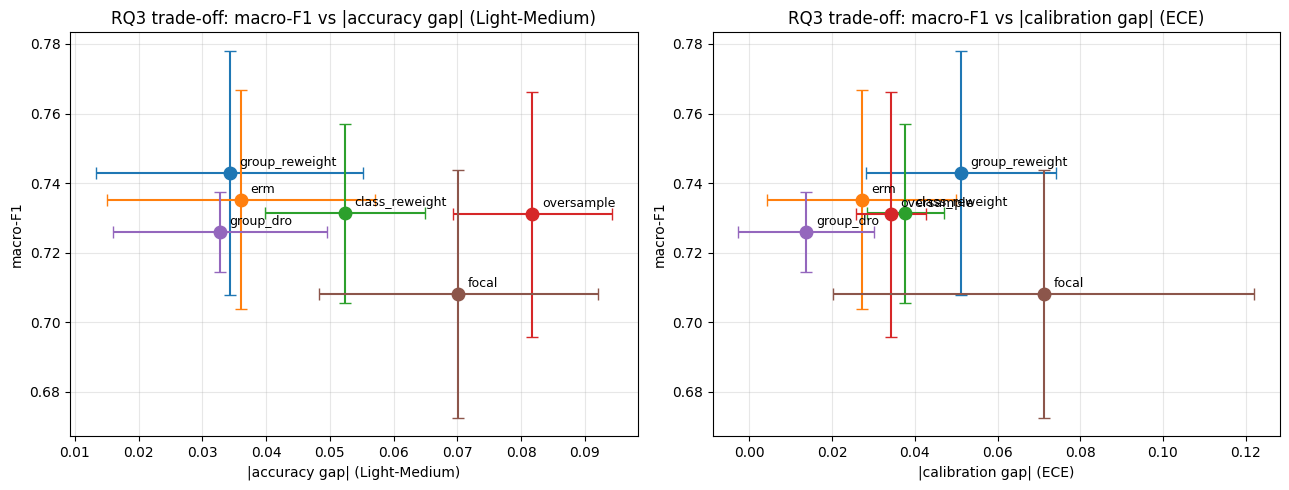


Best overall macro-F1 : group_reweight (0.743)
Smallest calibration gap: group_dro (0.014)
Best severe-class F1    : group_reweight (0.595)

Saved: rq3_mitigation_raw.csv, rq3_mitigation_summary.csv, rq3_tradeoff_curve.png, rq3_result.json

NOTE: interpret against the RQ1 null — with no resolved tone accuracy
gap on this corpus, the informative columns are the CALIBRATION gap and
SEVERE-CLASS F1, not the accuracy gap.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, gapcol, gapsd, name in [
        (axes[0], "accgap_mean", "accgap_std", "|accuracy gap| (Light-Medium)"),
        (axes[1], "ecegap_mean", "ecegap_std", "|calibration gap| (ECE)")]:
    for r in agg.itertuples():
        ax.errorbar(getattr(r, gapcol), r.f1_mean,
                    xerr=getattr(r, gapsd) or 0, yerr=r.f1_std or 0,
                    fmt="o", capsize=4, markersize=9)
        ax.annotate(r.strategy, (getattr(r, gapcol), r.f1_mean),
                    textcoords="offset points", xytext=(7, 5), fontsize=9)
    ax.set_xlabel(name); ax.set_ylabel("macro-F1")
    ax.set_title(f"RQ3 trade-off: macro-F1 vs {name}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK, "rq3_tradeoff_curve.png"), dpi=120)
plt.show()

best_f1 = agg.iloc[0]
best_ece = agg.sort_values("ecegap_mean").iloc[0]
best_sev = agg.sort_values("f1severe_mean", ascending=False).iloc[0]
print(f"\nBest overall macro-F1 : {best_f1.strategy} ({best_f1.f1_mean:.3f})")
print(f"Smallest calibration gap: {best_ece.strategy} ({best_ece.ecegap_mean:.3f})")
print(f"Best severe-class F1    : {best_sev.strategy} ({best_sev.f1severe_mean:.3f})")

with open(os.path.join(WORK, "rq3_result.json"), "w") as fh:
    json.dump(dict(best_macro_f1=str(best_f1.strategy),
                   best_calibration=str(best_ece.strategy),
                   best_severe=str(best_sev.strategy),
                   strategies=STRATEGIES, seeds=SEEDS, epochs=EPOCHS),
              fh, indent=2)
print("\nSaved: rq3_mitigation_raw.csv, rq3_mitigation_summary.csv, "
      "rq3_tradeoff_curve.png, rq3_result.json")
print("\nNOTE: interpret against the RQ1 null — with no resolved tone accuracy")
print("gap on this corpus, the informative columns are the CALIBRATION gap and")
print("SEVERE-CLASS F1, not the accuracy gap.")